In [99]:
from dotenv import load_dotenv
load_dotenv()

True

In [100]:
from langgraph.graph import StateGraph,MessagesState,START,END

In [101]:
class chatState(MessagesState):
    summary : str

In [102]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model= 'gpt-4o-mini')

In [103]:
from langchain_core.messages import SystemMessage

In [104]:
def chatNode(state: chatState):
    messages = []
    if state.get('summary'):
        messages.append(state['summary'])
    messages.extend(state['messages'])

    response = llm.invoke(messages)
    return {'messages':[response]}

In [105]:
from langchain_core.messages import RemoveMessage,SystemMessage

In [106]:
def summarize(state: chatState):
    if state.get('summary'):
        prompt = f'''this is the previous summary {state['summary']} 
            and these are the new messages {state['messages'][:-2]} summarize both of them'''
    else:
        prompt = f'summarize the messages {state['messages'][:-2]}'
    response = llm.invoke(prompt)


    # before returning delete the messages 
    messages_to_delete = state['messages'][:-2]

    return {'summary': [SystemMessage(content=response.content)],
            'messages':[RemoveMessage(id = m.id) for m in messages_to_delete]}

In [107]:
def route_summarize(state: chatState):
    if len(state['messages']) > 6:
        return True
    else:
        return False

In [108]:
builder = StateGraph(state_schema=chatState)
builder.add_node('chatNode',chatNode)
builder.add_node('summarize',summarize)
builder.add_edge(START,'chatNode')
builder.add_conditional_edges(
    source = 'chatNode',
    path = route_summarize,
    path_map = {
        True : 'summarize',
        False : END
    }
)


In [109]:
from langgraph.checkpoint.memory import InMemorySaver
cp = InMemorySaver()

In [110]:
graph = builder.compile(checkpointer= cp)

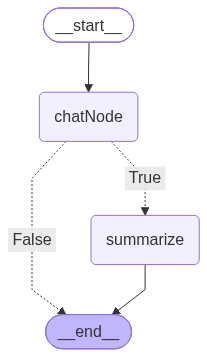

In [111]:
graph

In [121]:
config2 = {'configurable':{'thread_id':'session-2'}}
def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config2)
    return out

In [124]:
def show_state():
    snap = graph.get_state(config =config2)
    vals =  snap.values
    print('--STATE---')
    print('summary:',vals.get('summary',''))
    print('num_messages:',len(vals.get('messages',[])))
    print('messages')
    for m in vals.get('messages',[]):
        print('-',type(m).__name__,':',m.content[:80])

In [119]:
from langchain_core.messages import HumanMessage

In [ ]:
run_turn('what quantum physics talk about')


In [125]:
show_state()

--STATE---
summary: 
num_messages: 2
messages
- HumanMessage : what quantum physics talk about
- AIMessage : Quantum physics, also known as quantum mechanics, is a fundamental branch of phy


In [126]:
run_turn('How is Albert Einstien related?')
show_state()

--STATE---
summary: 
num_messages: 4
messages
- HumanMessage : what quantum physics talk about
- AIMessage : Quantum physics, also known as quantum mechanics, is a fundamental branch of phy
- HumanMessage : How is Albert Einstien related?
- AIMessage : Albert Einstein is deeply connected to the development of modern physics, includ


In [127]:
run_turn('What are some of Einstien"s fampus work')
show_state()

--STATE---
summary: 
num_messages: 6
messages
- HumanMessage : what quantum physics talk about
- AIMessage : Quantum physics, also known as quantum mechanics, is a fundamental branch of phy
- HumanMessage : How is Albert Einstien related?
- AIMessage : Albert Einstein is deeply connected to the development of modern physics, includ
- HumanMessage : What are some of Einstien"s fampus work
- AIMessage : Albert Einstein made numerous groundbreaking contributions to physics that have 


In [128]:
run_turn('Explain special theory of relativity')
show_state()

--STATE---
summary: [SystemMessage(content="The conversation covers two main topics related to quantum physics and Albert Einstein's contributions:\n\n1. **Quantum Physics Overview**:\n   - Quantum physics (quantum mechanics) focuses on the behavior of matter and energy at atomic and subatomic levels.\n   - Key concepts include:\n     - **Wave-Particle Duality**: Particles exhibit both wave-like and particle-like properties.\n     - **Quantization of Energy**: Energy exists in discrete packets (quanta).\n     - **Uncertainty Principle**: Certain properties (e.g., position and momentum) can't be known simultaneously with precision.\n     - **Superposition**: Particles can be in multiple states until measured.\n     - **Entanglement**: Particles' states can become linked regardless of distance.\n     - **Collapse of the Wavefunction**: Observation causes a quantum system to settle into one definite state.\n     - **Quantum Tunneling**: Particles can pass through barriers they wouldn’t cl